# 10v5_04 — STANDARD_ONLY provenance audit (audit only: no training, no MRR)

**Question.** Are the same-source references that `mirror_aware` removes mostly benchmark
duplicates, or independent-looking measurements that would legitimately be available for an
unpublished hidden-test spectrum?

**`ingest_lib` is not a leakage boundary by definition.** It is a dataset/library grouping. It is
not automatically an acquisition session, an experimental replicate, a duplicate spectrum, or the
hidden-test leakage boundary. Whether source-level exclusion is justified is determined here from
identity tiers and metadata, never from library names.

**Inputs (all existing).** The TL_EVAL manifest and regimes (`10v5_03`), the TL_EVAL QCR shards,
and the settled HOST QCR. Tiers are the QCR `tier` column, the output of the existing
`classify_identity_tier`; no second classifier is used. Spectrum metadata comes from
`train_spectrum_metadata`, and the T1 peak hash from `bundle/ref_meta.parquet` when exported. No
similarity is recomputed.

**Semantic labels.** T1 is `EXACT_DUPLICATE_LIKE` and T2 is `NEAR_DUPLICATE_LIKE`. T3 and T4 are
`INDEPENDENT_REFERENCE_LIKE`. That label is never upgraded to "independent" without real
acquisition provenance.

**Pre-registered T2 rule** (`casmi.qcr.protocols.T2_RULE`, fixed before any output). Among
STANDARD_ONLY queries, `q_t34` is the share whose standard-selected truth references include at
least one T3/T4:
* `q_t34 ≥ 0.50` gives `STRICT_ONLY`: test_simulated excludes T1 and T2 and allows T3/T4.
* Otherwise it gives `STRICT_AND_RELAXED`: strict (exclude T1+T2) and relaxed (exclude T1 only)
  are both carried as sensitivities. Relaxed is never chosen by MRR.

In [1]:
import sys, json
from pathlib import Path

REPO_ROOT = Path.cwd()
if not (REPO_ROOT / 'src').exists() and (REPO_ROOT.parent / 'src').exists():
    REPO_ROOT = REPO_ROOT.parent
if str(REPO_ROOT / 'src') not in sys.path:
    sys.path.insert(0, str(REPO_ROOT / 'src'))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from casmi.paths import get_project_paths
from casmi.io.artifacts import load_artifact
from casmi.qcr.context import config_hash, v4b_paths, v5_paths
from casmi.qcr.fingerprint import code_version
from casmi.qcr.protocols import (PROTOCOL_DEFS, T2_RULE, assert_walk_complete, check_existing_flag_parity, coverage_row,
                                 protocol_counts_from_shards, protocol_definition_record, protocol_semantics_table, t2_policy)
from casmi.qcr.settlement import identity_thresholds, load_settlement_or_refuse
from casmi.ranking.manifests import load_manifest
from casmi.validation.provenance import (NOT_AVAILABLE, PAIR_QCR_COLS, TIER_ORDER, build_truth_reference_pairs, connectivity_source_summary,
                                         provenance_by_source, query_level_summary, session_fields_available, t2_rule_inputs, tier_shares)
from casmi.validation.regime_audit import MODE_A_MIRROR, REF_ABSENT, STANDARD_ONLY, load_regimes, project_route_v2, summary_row

pd.set_option('display.max_columns', 60); pd.set_option('display.width', 220)
paths = get_project_paths()
vp, D = v4b_paths(paths), v5_paths(paths)
PROV, PROTO = D['root'] / 'provenance', D['root'] / 'protocols'
for d in (PROV, PROTO):
    d.mkdir(parents=True, exist_ok=True)
settlement = load_settlement_or_refuse(vp.settlement_json)
ARTS = settlement['evidence_artifacts']
THR = identity_thresholds(settlement['similarity_config'])
print('T2 rule (pre-registered):', T2_RULE['rule'])

T2 rule (pre-registered): q_t34 >= 0.50 -> STRICT_ONLY (test_simulated primary = exclude T1+T2); else STRICT_AND_RELAXED (carry strict + relaxed as sensitivities; relaxed is never chosen by MRR)


## 1. Inputs: TL_EVAL regimes, truth QCR rows, spectrum metadata, peak hashes, session fields

In [2]:
TL_MAN, _ = load_manifest('TL_EVAL', D['manifests'])
REG = load_regimes('TL_EVAL', D['root'] / 'regimes')
SO_IDS = REG.loc[REG['regime'] == STANDARD_ONLY, 'query_id'].tolist()
print(f'TL_EVAL queries: {len(REG)} | STANDARD_ONLY: {len(SO_IDS)} | regime counts: {REG["regime"].value_counts().to_dict()}')

tm = load_artifact('train_spectrum_metadata')
SESSION = session_fields_available(tm.columns)
print('acquisition-session-like fields in the metadata:', SESSION)
meta = pd.DataFrame({'precursor_mz': tm['precursor_mz'].to_numpy(float), 'ce': tm['ce_mean'].to_numpy(float)}, index=tm['train_spectrum_id'].astype(str))
PEAK_HASH = None
if (D['bundle'] / 'ref_meta.parquet').exists():
    rm = pd.read_parquet(D['bundle'] / 'ref_meta.parquet', columns=['ref_spectrum_id', 'peak_hash'])
    PEAK_HASH = rm.set_index('ref_spectrum_id')['peak_hash'] if rm['peak_hash'].notna().any() else None
print('exported T1 peak hashes:', 'AVAILABLE' if PEAK_HASH is not None else NOT_AVAILABLE)

TL_QCR = sorted((D['qcr'] / 'TL_EVAL' / 'qcr' / 'shards').glob('part-*.parquet'))
TL_PAIRS = sorted((D['qcr'] / 'TL_EVAL' / 'qcr_pairs' / 'shards').glob('part-*.parquet'))
TL_POOL = pd.read_parquet(D['features'] / 'units' / 'TL_EVAL_pool.parquet')
truth_qcr = pd.concat([(lambda q: q[q['is_true'].astype(bool)])(pd.read_parquet(p, columns=PAIR_QCR_COLS)) for p in TL_QCR], ignore_index=True)
truth_pairs = pd.concat([(lambda q: q[q['is_true'].astype(bool)])(pd.read_parquet(p, columns=['query_id', 'candidate_key', 'is_true', 'exhausted']))
                         for p in TL_PAIRS], ignore_index=True)
# completeness: a STANDARD_ONLY truth never reached 5 mirror_aware acceptances, so its walk must have exhausted the list
so_ex = truth_pairs[truth_pairs['query_id'].isin(set(SO_IDS))]['exhausted'].astype(bool)
print(f'STANDARD_ONLY truth walks exhausted (all truth references present in QCR): {int(so_ex.sum())}/{len(so_ex)}')
assert so_ex.all(), 'a STANDARD_ONLY truth walk stopped early -- its full reference list is not in QCR'

TL_EVAL queries: 1000 | STANDARD_ONLY: 984 | regime counts: {'STANDARD_ONLY': 984, 'MODE_A_MIRROR': 14, 'REF_ABSENT': 2}
acquisition-session-like fields in the metadata: NOT_AVAILABLE
exported T1 peak hashes: AVAILABLE
STANDARD_ONLY truth walks exhausted (all truth references present in QCR): 984/984


## 2. Truth-reference pair table (every truth reference of every TL_EVAL query; STANDARD_ONLY is primary)

In [3]:
PAIRS = build_truth_reference_pairs(truth_qcr, REG['query_id'], meta, peak_hash=PEAK_HASH, identity_thresholds=THR, session_fields=SESSION)
PAIRS = PAIRS.merge(REG[['query_id', 'regime']], on='query_id', how='left')
SO_PAIRS = PAIRS[PAIRS['regime'] == STANDARD_ONLY]
SO_PAIRS.to_parquet(PROV / 'standard_only_reference_pairs.parquet', index=False)
print(f'STANDARD_ONLY truth reference pairs: {len(SO_PAIRS):,} ({int(SO_PAIRS["same_source"].sum()):,} same-source)')
if PEAK_HASH is not None:
    t1_hash = SO_PAIRS[SO_PAIRS['tier'] == 'T1']['peak_hash_equal']
    print('T1 rows whose exported peak hashes are equal (consistency with the classifier):', f'{int(t1_hash.sum())}/{len(t1_hash)}')

STANDARD_ONLY truth reference pairs: 6,011 (6,011 same-source)
T1 rows whose exported peak hashes are equal (consistency with the classifier): 0/0


## 3. Tier breakdown. Query level is primary; pair level is secondary, because well-measured molecules dominate pair counts.

In [4]:
QSUM = {}
for reg in (STANDARD_ONLY, MODE_A_MIRROR, REF_ABSENT):
    ids = REG.loc[REG['regime'] == reg, 'query_id'].tolist()
    QSUM[reg] = query_level_summary(PAIRS[PAIRS['regime'] == reg], ids)
QSUM[STANDARD_ONLY].to_parquet(PROV / 'standard_only_query_summary.parquet', index=False)
host_q = pd.read_parquet(vp.host_processed / 'host_holdout_spectra.parquet')
hq = pd.read_parquet(ARTS['host_qcr'], columns=PAIR_QCR_COLS)
hq = hq[hq['is_true'].astype(bool)]
hmeta = meta   # HOST queries are train spectra
HOST_PAIRS = build_truth_reference_pairs(hq, host_q['query_id'], hmeta, peak_hash=PEAK_HASH, identity_thresholds=THR, session_fields=SESSION)
QSUM['HOST'] = query_level_summary(HOST_PAIRS, host_q['query_id'].tolist())
TIERS = {reg: tier_shares(PAIRS[PAIRS['regime'] == reg] if reg != 'HOST' else HOST_PAIRS, QSUM[reg]) for reg in QSUM}
ql = pd.DataFrame({reg: t['query_level'] for reg, t in TIERS.items()}).T
ql.insert(0, 'n_queries', [TIERS[r]['n_queries'] for r in ql.index])
print('QUERY-LEVEL (primary): share of queries whose truth references / standard-selected top-5 contain each tier')
display(ql.round(3))
print('PAIR-LEVEL (secondary):')
display(pd.DataFrame({reg: t['pair_level_tier_share'] for reg, t in TIERS.items()}).T.round(3))
display(QSUM[STANDARD_ONLY][['highest_risk_tier', 'best_non_T1_T2_tier']].apply(lambda s: s.value_counts(normalize=True)).round(3))

QUERY-LEVEL (primary): share of queries whose truth references / standard-selected top-5 contain each tier


,n_queries,has_T1,has_T2,has_T3,has_T4,selected_has_T1,selected_has_T2,selected_has_T3,selected_has_T4,selected_all_T1_T2,selected_has_T3_T4
STANDARD_ONLY,984,0.0,0.005,0.253,0.991,0.0,0.005,0.253,0.990,0.0,1.0
MODE_A_MIRROR,14,0.0,0.000,0.286,1.000,0.0,0.000,0.286,1.000,0.0,1.0
REF_ABSENT,2,0.0,0.000,0.000,0.000,0.0,0.000,0.000,0.000,0.0,0.0
HOST,1184,0.0,0.002,0.261,1.000,0.0,0.002,0.252,0.976,0.0,1.0


PAIR-LEVEL (secondary):


,T1,T2,T3,T4
STANDARD_ONLY,0.0,0.001,0.057,0.942
MODE_A_MIRROR,0.0,0.000,0.135,0.865
REF_ABSENT,0.0,0.000,0.000,0.000
HOST,0.0,0.000,0.159,0.841


,highest_risk_tier,best_non_T1_T2_tier
T2,0.005,NaN
T3,0.249,0.253
T4,0.746,0.747


## 4. Selected-reference breakdown: what the standard top-5 actually feeds the model

In [5]:
sel = SO_PAIRS[SO_PAIRS['selected_standard_top5']]
display(sel['tier'].value_counts(normalize=True).reindex(list(TIER_ORDER), fill_value=0).rename('selected_pair_share').to_frame().round(3))
q = QSUM[STANDARD_ONLY]
display(pd.Series({'selected contains T1': q['selected_has_T1'].mean(), 'selected contains T2': q['selected_has_T2'].mean(),
                   'selected contains T3': q['selected_has_T3'].mean(), 'selected contains T4': q['selected_has_T4'].mean(),
                   'selected all T1/T2': q['selected_all_T1_T2'].mean(), 'selected has >=1 T3/T4': q['selected_has_T3_T4'].mean()},
                  name='share_of_STANDARD_ONLY_queries').to_frame().round(3))

,selected_pair_share
tier,
T1,0.000
T2,0.001
T3,0.084
T4,0.915


,share_of_STANDARD_ONLY_queries
selected contains T1,0.000
selected contains T2,0.005
selected contains T3,0.253
selected contains T4,0.990
selected all T1/T2,0.000
selected has >=1 T3/T4,1.000


## 5. Acquisition-independence diagnostics (same-source truth references; missing metadata stays UNKNOWN / NOT_AVAILABLE)

In [6]:
same = SO_PAIRS[SO_PAIRS['same_source']]
diff_cols = ['differs_spectrum_id', 'differs_collision_energy', 'differs_adduct', 'differs_polarity', 'differs_instrument',
             'precursor_beyond_t2_tolerance', 'precursor_beyond_t3_tolerance', 'differs_session']
indep = pd.DataFrame({c: same[c].astype(str).value_counts(normalize=True) for c in diff_cols}).fillna(0).T
display(indep.round(3))
print('session/run/batch/file identifiers:', SESSION, '-- independence is NOT inferred from missing metadata')
display(pd.crosstab(same['semantic_category'], same['differs_collision_energy'], normalize='index').round(3))

,DIFFERENT,NOT_AVAILABLE,SAME
differs_spectrum_id,1.000,0.0,0.000
differs_collision_energy,0.685,0.0,0.315
differs_adduct,0.570,0.0,0.430
differs_polarity,0.303,0.0,0.697
differs_instrument,0.000,0.0,1.000
precursor_beyond_t2_tolerance,0.570,0.0,0.430
precursor_beyond_t3_tolerance,0.570,0.0,0.430
differs_session,0.000,1.0,0.000


session/run/batch/file identifiers: NOT_AVAILABLE -- independence is NOT inferred from missing metadata


differs_collision_energy,DIFFERENT,SAME
semantic_category,,
INDEPENDENT_REFERENCE_LIKE,0.685,0.315
NEAR_DUPLICATE_LIKE,0.600,0.400


## 6. Source-library structure (TL_EVAL). Is one library responsible?

In [7]:
by_src = provenance_by_source(REG, QSUM[STANDARD_ONLY])
by_src.to_csv(PROV / 'provenance_by_source.csv', index=False)
display(by_src.sort_values('n_queries', ascending=False).round(3))

,source,n_queries,STANDARD_ONLY_share,MODE_A_MIRROR_share,n_standard_only,so_selected_has_T1_share,so_selected_has_T2_share,so_selected_has_T3_T4_share
0,enveda-180,1000,0.984,0.014,984,0.0,0.005,1.0


## 7. Connectivity-level duplication: A (single-source molecule) vs B (multi-source molecule, other-source references excluded or absent)

In [8]:
mirror_elig = truth_qcr.groupby('query_id')['eligible_mirror_aware'].sum()
conn = connectivity_source_summary(TL_MAN[['query_id', 'connectivity_key', 'source']], tm, mirror_eligible_counts=mirror_elig)
conn = conn.merge(REG[['query_id', 'regime']], on='query_id')
conn.to_parquet(PROV / 'connectivity_source_summary.parquet', index=False)
display(conn.groupby('regime')[['n_source_libraries', 'n_spectra_total', 'n_same_source_spectra', 'n_cross_source_spectra']].median())
display(pd.crosstab(conn['regime'], conn['pattern']))
del tm

,n_source_libraries,n_spectra_total,n_same_source_spectra,n_cross_source_spectra
regime,,,,
MODE_A_MIRROR,2.0,15.0,5.0,9.0
REF_ABSENT,1.0,1.0,0.0,0.0
STANDARD_ONLY,1.0,7.0,6.0,0.0


pattern,A_SINGLE_SOURCE_ONLY,B_MULTI_SOURCE_BUT_EXCLUDED_OR_OTHER
regime,,
MODE_A_MIRROR,0,14
REF_ABSENT,2,0
STANDARD_ONLY,984,0


## 8. Pre-registered T2 rule → test_simulated definition (provenance inputs only)

In [9]:
inputs = t2_rule_inputs(QSUM[STANDARD_ONLY])
T2 = t2_policy(inputs['q_t34'], inputs['q_t12_only'])
print(json.dumps({k: T2[k] for k in ('t2_policy', 'primary', 'protocols', 'q_t34', 'q_t12_only')}, indent=1), '| n queries with selected refs:',
      inputs['n_queries_with_selected_refs'])
CODE_VERSION, CFG_HASH = code_version(), config_hash(settlement['similarity_config'])
definitions = {p: protocol_definition_record(PROTOCOL_DEFS[p], T2, CODE_VERSION, CFG_HASH) for p in ['mirror_aware', 'standard', *T2['protocols']]}
(PROTO / 'test_simulated_definition.json').write_text(json.dumps({'t2_decision': T2, 'primary': T2['primary'], 'definitions': definitions},
                                                                 indent=2, default=str), encoding='utf-8')
print('definition sha256 (primary):', definitions[T2['primary']]['definition_sha256'])

{
 "t2_policy": "STRICT_ONLY",
 "primary": "test_simulated_strict",
 "protocols": [
  "test_simulated_strict"
 ],
 "q_t34": 1.0,
 "q_t12_only": 0.0
} | n queries with selected refs: 984
definition sha256 (primary): 7161d0f8b8721fc43288954823e7f75d5937f734bb755f205da263ccad4a3d9d


## 9. Protocol coverage and truth/decoy asymmetry on TL_EVAL (existing QCR; filter + count only)

In [10]:
PROTOCOLS = ['standard', 'mirror_aware', 'test_simulated_strict', 'test_simulated_relaxed']   # both sensitivities are always REPORTED
sample = pd.read_parquet(TL_QCR[0], columns=['query_id', 'candidate_key', 'tier', 'ref_source', 'query_source', 'eligible_mirror_aware', 'eligible_standard'])
parity = check_existing_flag_parity(sample)
print('filter parity with the existing eligibility flags (mismatching rows, must be 0):', parity)
assert all(v == 0 for v in parity.values())
COUNTS = protocol_counts_from_shards(TL_QCR, TL_PAIRS, TL_POOL, PROTOCOLS)
for p in ('test_simulated_strict', 'test_simulated_relaxed', 'standard'):
    assert_walk_complete(COUNTS[p])
    COUNTS[p].to_parquet(PROTO / f'TL_EVAL_{p}_counts.parquet', index=False)
COUNTS['mirror_aware'].to_parquet(PROTO / 'TL_EVAL_mirror_aware_counts.parquet', index=False)
coverage = pd.DataFrame([coverage_row(COUNTS[p], TL_MAN['query_id'], p) for p in PROTOCOLS])
coverage['label'] = coverage['protocol'].map(lambda p: PROTOCOL_DEFS[p].label)
coverage.to_csv(PROTO / 'protocol_coverage.csv', index=False)
display(coverage.round(4))

filter parity with the existing eligibility flags (mismatching rows, must be 0): {'mirror_aware': 0, 'standard': 0}


c:\Users\myben\OneDrive\Documents\Enveda\src\casmi\qcr\protocols.py:293: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  c["exhausted"] = c["exhausted"].fillna(True).astype(bool)
c:\Users\myben\OneDrive\Documents\Enveda\src\casmi\qcr\protocols.py:293: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  c["exhausted"] = c["exhausted"].fillna(True).astype(bool)
c:\Users\myben\OneDrive\Documents\Enveda\src\casmi\qcr\protocols.py:293: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call res

,protocol,n_queries,truth_in_pool,truth_ge1,truth_ge3,truth_ge5,median_eligible_truth_refs,decoy_ge1_share_pooled,decoy_ge1_share_mean_per_query,decoy_ge1_share_median_per_query,reference_availability_gap,label
0,standard,1000,1.0,0.998,0.891,0.600,6.0,1.0000,1.0000,1.0000,-0.0020,STANDARD -- OPTIMISTIC / DUPLICATE-PERMITTING ...
1,mirror_aware,1000,1.0,0.014,0.014,0.014,0.0,0.1831,0.2142,0.1881,-0.1691,benchmark mirror-aware (historical primary)
2,test_simulated_strict,1000,1.0,0.998,0.890,0.600,6.0,1.0000,1.0000,1.0000,-0.0020,"test-simulated STRICT: exclude T1+T2, allow sa..."
3,test_simulated_relaxed,1000,1.0,0.998,0.891,0.600,6.0,1.0000,1.0000,1.0000,-0.0020,test-simulated RELAXED: exclude T1 only (T2 se...


## 10. Semantic comparison with the CURRENT hidden-test inference (`casmi_infer`; not modified here)

In [11]:
bundle_cfg = json.loads((D['bundle'] / 'config.json').read_text(encoding='utf-8')) if (D['bundle'] / 'config.json').exists() else None
sem = protocol_semantics_table(T2['primary'], bundle_cfg)
sem.to_csv(PROTO / 'protocol_semantics.csv', index=False)
display(sem)
print('mismatches vs hidden Kaggle inference:', sem.loc[sem['mismatch_testsim_vs_kaggle'], 'property'].tolist(),
      '-- recorded for a later, separate production decision; casmi_infer is NOT changed here')

,property,benchmark_mirror_aware,test_simulated_strict,hidden_kaggle_casmi_infer,mismatch_testsim_vs_kaggle
0,source exclusion,ref_source != query_source,NONE,NONE (exclude_sources = {}),False
1,T1 exclusion,yes,yes,yes (peak hash),False
2,T2 exclusion,yes,yes,NO (identity peaks not shipped),True
3,T3/T4 allowed,yes (other-source only),yes (any source),yes (any source),False
4,self-reference possible?,no (walk excludes query id),no (walk excludes query id),no (hidden query is not in the library),False
5,query published?,yes (benchmark query is a library spectrum),yes (benchmark query is a library spectrum),no (unpublished),True
6,reference source known?,yes,yes,yes (exported ref_meta),False


mismatches vs hidden Kaggle inference: ['T2 exclusion', 'query published?'] -- recorded for a later, separate production decision; casmi_infer is NOT changed here


## 11. Routing (v5.2 rule: the largest regime decides; supersedes the 0.50 mirror-coverage rule)

In [12]:
s = summary_row(REG)
route = project_route_v2(s['mode_a_share'], s['standard_only_share'], s['ref_absent_share'])
old = json.loads((D['root'] / 'project_route.json').read_text(encoding='utf-8')) if (D['root'] / 'project_route.json').exists() else {}
(D['root'] / 'project_route.json').write_text(json.dumps({**route, 'legacy_v5_1_route': old.get('project_route', old.get('legacy_v5_1_route'))},
                                                         indent=2, default=str), encoding='utf-8')

643

## 12. Figures

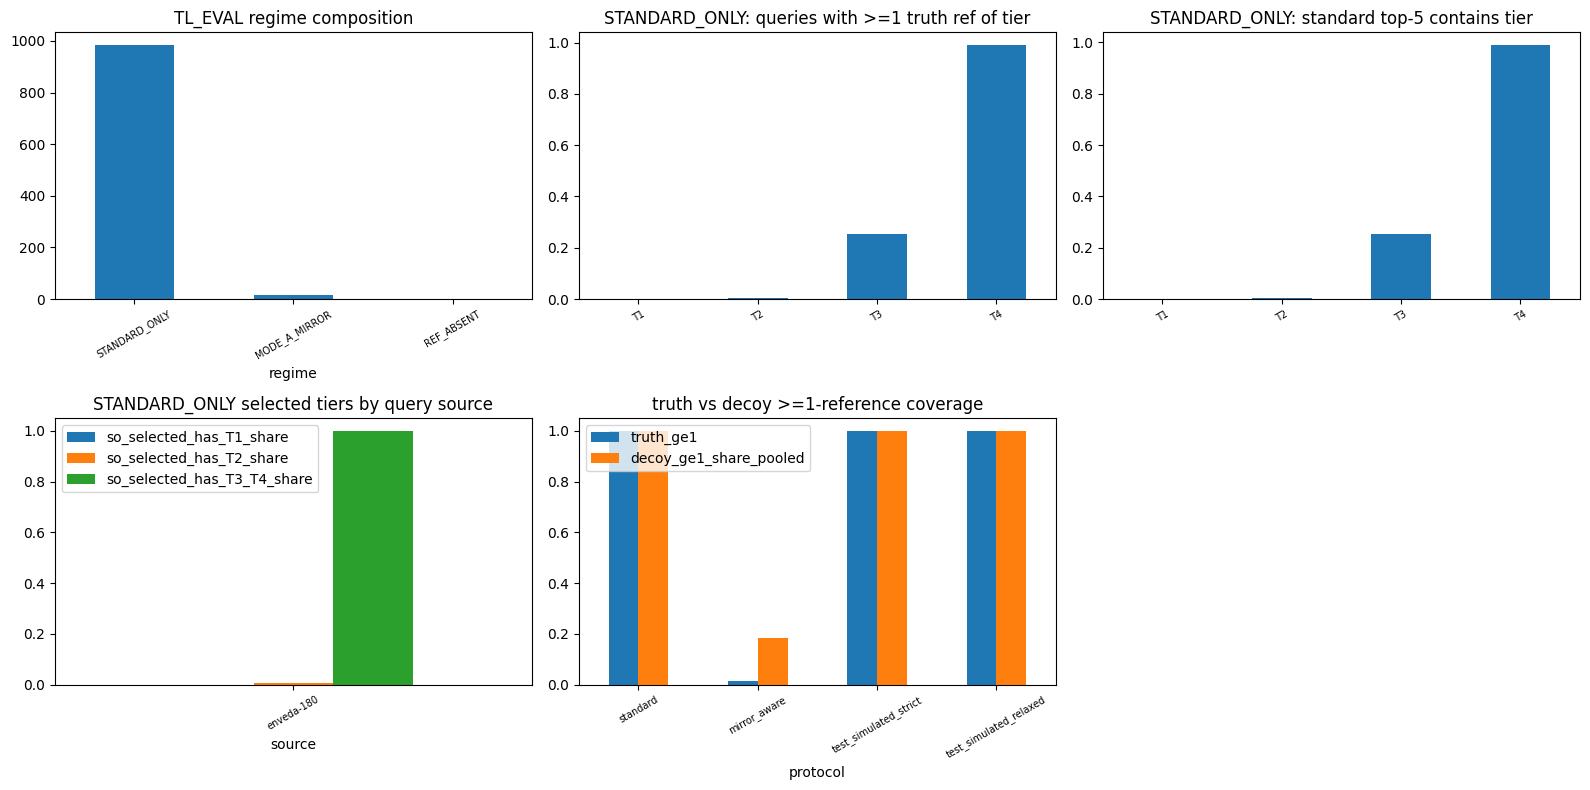

In [13]:
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
REG['regime'].value_counts().plot.bar(ax=axes[0, 0], title='TL_EVAL regime composition')
pd.Series({t: QSUM[STANDARD_ONLY][f'has_{t}'].mean() for t in TIER_ORDER}).plot.bar(ax=axes[0, 1], title='STANDARD_ONLY: queries with >=1 truth ref of tier')
pd.Series({t: QSUM[STANDARD_ONLY][f'selected_has_{t}'].mean() for t in TIER_ORDER}).plot.bar(ax=axes[0, 2], title='STANDARD_ONLY: standard top-5 contains tier')
by_src.set_index('source')[['so_selected_has_T1_share', 'so_selected_has_T2_share', 'so_selected_has_T3_T4_share']].plot.bar(ax=axes[1, 0], title='STANDARD_ONLY selected tiers by query source')
coverage.set_index('protocol')[['truth_ge1', 'decoy_ge1_share_pooled']].plot.bar(ax=axes[1, 1], title='truth vs decoy >=1-reference coverage')
axes[1, 2].axis('off')
for ax in axes.ravel():
    ax.tick_params(axis='x', labelsize=7, rotation=30)
fig.tight_layout(); fig.savefig(D['figures'] / 'v52_provenance.png', dpi=120); plt.show()

## 13. Summary (runtime-derived)

In [14]:
t = TIERS[STANDARD_ONLY]['query_level']
summary = {'n_standard_only': len(SO_IDS), 'tier_summary': TIERS, 't2_decision': T2, 'coverage': coverage.to_dict('records'), 'route': route,
           'session_fields': SESSION, 'peak_hash': 'AVAILABLE' if PEAK_HASH is not None else NOT_AVAILABLE}
(PROV / 'tier_summary.json').write_text(json.dumps(summary, indent=2, default=str), encoding='utf-8')
print(f'STANDARD_ONLY queries: {len(SO_IDS)}\n')
print('Truth-reference availability (share of STANDARD_ONLY queries with >=1 truth reference of tier):')
for tier in TIER_ORDER:
    print(f'  {tier}: {100 * t[f"has_{tier}"]:.1f}%')
print('\nSelected truth references (standard top-5):')
print(f'  T1/T2-only share: {100 * t["selected_all_T1_T2"]:.1f}%')
print(f'  has T3/T4 share:  {100 * t["selected_has_T3_T4"]:.1f}%')
print(f'\nT2 POLICY: {T2["t2_policy"]}')
d = definitions[T2['primary']]
print(f"PROPOSED TEST-SIMULATED PROTOCOL: {d['protocol_name']} -- source exclusion {d['source_exclusion']}, exclude T1 {d['exclude_T1']}, "
      f"exclude T2 {d['exclude_T2']}, allow T3 {d['allow_T3']}, allow T4 {d['allow_T4']}, top-{d['top_k_refs']} in compat order")
print(f"\nPROJECT ROUTE: {route['project_route']} (dominant regime {route['dominant_regime']})")

STANDARD_ONLY queries: 984

Truth-reference availability (share of STANDARD_ONLY queries with >=1 truth reference of tier):
  T1: 0.0%
  T2: 0.5%
  T3: 25.3%
  T4: 99.1%

Selected truth references (standard top-5):
  T1/T2-only share: 0.0%
  has T3/T4 share:  100.0%

T2 POLICY: STRICT_ONLY
PROPOSED TEST-SIMULATED PROTOCOL: test_simulated_strict -- source exclusion NONE, exclude T1 True, exclude T2 True, allow T3 True, allow T4 True, top-5 in compat order

PROJECT ROUTE: RESOLVE_TEST_PROTOCOL (dominant regime STANDARD_ONLY)
